Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os

os.makedirs('output', exist_ok=True)

Read Data File

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Data analytics/Week 03/messy_dataset_Mukesh.csv')

print("Shape:", df.shape)
print()
print("Raw data:")
print(df.to_string())
print()
print("Data types:")
print(df.dtypes)

Shape: (10, 6)

Raw data:
     ID     Name           Age Country               Salary   Join Date
0   1.0    Alice            25      NZ                55000  15/01/2020
1   2.0      Bob           NaN      NZ                60000  20/02/2020
2   2.0      Bob            30      NZ                  NaN  20/02/2020
3   4.0  Charlie            35     AUS                72000         NaN
4   5.0    David  thirty-eight      NZ                68000   1/11/2019
5   NaN      Eve            29      AU                59000  2019-13-01
6   7.0      NaN            40      NZ  sixty five thousand  30/05/2018
7   8.0    Grace            22     NaN                64000  25/07/2021
8   9.0    Heidi           NaN     AUS                  NaN  25/07/2021
9  10.0     Ivan            27      NZ                58000  15/03/2019

Data types:
ID           float64
Name          object
Age           object
Country       object
Salary        object
Join Date     object
dtype: object


In [3]:
print("=" * 50)
print("PROBLEMS IDENTIFIED IN THE DATASET")
print("=" * 50)

print("\n1. Missing values per column:")
print(df.isnull().sum())

print(f"\n2. Duplicate rows (same ID+Name):")
dups = df[df.duplicated(subset=['ID', 'Name'], keep=False)]
print(dups.to_string())

print(f"\n3. Non-numeric values in Age column:")
age_issues = df[pd.to_numeric(df['Age'], errors='coerce').isnull() &
                df['Age'].notna()]
print(age_issues[['ID', 'Name', 'Age']])

print(f"\n4. Non-numeric values in Salary column:")
sal_issues = df[pd.to_numeric(df['Salary'], errors='coerce').isnull() &
                df['Salary'].notna()]
print(sal_issues[['ID', 'Name', 'Salary']])

print(f"\n5. Invalid/inconsistent dates in Join Date:")
print(df[['ID', 'Name', 'Join Date']])

PROBLEMS IDENTIFIED IN THE DATASET

1. Missing values per column:
ID           1
Name         1
Age          2
Country      1
Salary       2
Join Date    1
dtype: int64

2. Duplicate rows (same ID+Name):
    ID Name  Age Country Salary   Join Date
1  2.0  Bob  NaN      NZ  60000  20/02/2020
2  2.0  Bob   30      NZ    NaN  20/02/2020

3. Non-numeric values in Age column:
    ID   Name           Age
4  5.0  David  thirty-eight

4. Non-numeric values in Salary column:
    ID Name               Salary
6  7.0  NaN  sixty five thousand

5. Invalid/inconsistent dates in Join Date:
     ID     Name   Join Date
0   1.0    Alice  15/01/2020
1   2.0      Bob  20/02/2020
2   2.0      Bob  20/02/2020
3   4.0  Charlie         NaN
4   5.0    David   1/11/2019
5   NaN      Eve  2019-13-01
6   7.0      NaN  30/05/2018
7   8.0    Grace  25/07/2021
8   9.0    Heidi  25/07/2021
9  10.0     Ivan  15/03/2019


Data Cleaning

Fix text in age

In [4]:
# Replace written number with digit
df['Age'] = df['Age'].replace('thirty-eight', 38)

# Convert entire column to numeric
# Any remaining non-numeric values become NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print("Age column after fix:")
print(df[['ID','Name','Age']])

Age column after fix:
     ID     Name   Age
0   1.0    Alice  25.0
1   2.0      Bob   NaN
2   2.0      Bob  30.0
3   4.0  Charlie  35.0
4   5.0    David  38.0
5   NaN      Eve  29.0
6   7.0      NaN  40.0
7   8.0    Grace  22.0
8   9.0    Heidi   NaN
9  10.0     Ivan  27.0


Fix text in Salary

In [5]:
# Replace written number with digit
df['Salary'] = df['Salary'].replace(
    'sixty five thousand', 65000
)

# Convert entire column to numeric
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

print("Salary column after fix:")
print(df[['ID','Name','Salary']])

Salary column after fix:
     ID     Name   Salary
0   1.0    Alice  55000.0
1   2.0      Bob  60000.0
2   2.0      Bob      NaN
3   4.0  Charlie  72000.0
4   5.0    David  68000.0
5   NaN      Eve  59000.0
6   7.0      NaN  65000.0
7   8.0    Grace  64000.0
8   9.0    Heidi      NaN
9  10.0     Ivan  58000.0


Fix invalid date formats

In [6]:
# 2019-13-01 is invalid (month 13 does not exist)
# Likely intended as 13 January 2019
df['Join Date'] = df['Join Date'].replace(
    '2019-13-01', '13/01/2019'
)

# Parse all dates — dayfirst=True handles DD/MM/YYYY
df['Join Date'] = pd.to_datetime(
    df['Join Date'], dayfirst=True, errors='coerce'
)

print("Join Date after fix:")
print(df[['ID','Name','Join Date']])

Join Date after fix:
     ID     Name  Join Date
0   1.0    Alice 2020-01-15
1   2.0      Bob 2020-02-20
2   2.0      Bob 2020-02-20
3   4.0  Charlie        NaT
4   5.0    David 2019-11-01
5   NaN      Eve 2019-01-13
6   7.0      NaN 2018-05-30
7   8.0    Grace 2021-07-25
8   9.0    Heidi 2021-07-25
9  10.0     Ivan 2019-03-15


Fix country codes & adjust the values to a standard codes

In [7]:
# 'AU' and 'AUS' both mean Australia — standardise to AUS
df['Country'] = df['Country'].replace('AU', 'AUS')

print("Country values after fix:")
print(df['Country'].value_counts())
print()
print(df[['ID','Name','Country']])

Country values after fix:
Country
NZ     6
AUS    3
Name: count, dtype: int64

     ID     Name Country
0   1.0    Alice      NZ
1   2.0      Bob      NZ
2   2.0      Bob      NZ
3   4.0  Charlie     AUS
4   5.0    David      NZ
5   NaN      Eve     AUS
6   7.0      NaN      NZ
7   8.0    Grace     NaN
8   9.0    Heidi     AUS
9  10.0     Ivan      NZ


Remove Duplicates

In [8]:
# Bob row 1: Age=NaN, Salary=60000
# Bob row 2: Age=30,  Salary=NaN
# groupby().first() picks the first non-null in each column
df = df.sort_values(['ID','Name'])
df = df.groupby(
    ['ID','Name'], dropna=False
).first().reset_index()

print(f"Rows after deduplication: {len(df)}")
print()
print(df.to_string(index=False))

Rows after deduplication: 9

  ID    Name  Age Country  Salary  Join Date
 1.0   Alice 25.0      NZ 55000.0 2020-01-15
 2.0     Bob 30.0      NZ 60000.0 2020-02-20
 4.0 Charlie 35.0     AUS 72000.0        NaT
 5.0   David 38.0      NZ 68000.0 2019-11-01
 7.0     NaN 40.0      NZ 65000.0 2018-05-30
 8.0   Grace 22.0    None 64000.0 2021-07-25
 9.0   Heidi  NaN     AUS     NaN 2021-07-25
10.0    Ivan 27.0      NZ 58000.0 2019-03-15
 NaN     Eve 29.0     AUS 59000.0 2019-01-13


Remaining missing values

In [9]:
# Age and Salary: fill with column median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# Country: fill with most common value (mode)
df['Country'] = df['Country'].fillna(
    df['Country'].mode()[0]
)

# Name: fill with placeholder
df['Name'] = df['Name'].fillna('Unknown')

# ID: assign next available number
df['ID'] = df['ID'].fillna(df['ID'].max() + 1)

print("Missing values remaining:")
print(df.isnull().sum())
print()
print("Final clean dataset:")
print(df.to_string(index=False))

Missing values remaining:
ID           0
Name         0
Age          0
Country      0
Salary       0
Join Date    1
dtype: int64

Final clean dataset:
  ID    Name  Age Country  Salary  Join Date
 1.0   Alice 25.0      NZ 55000.0 2020-01-15
 2.0     Bob 30.0      NZ 60000.0 2020-02-20
 4.0 Charlie 35.0     AUS 72000.0        NaT
 5.0   David 38.0      NZ 68000.0 2019-11-01
 7.0 Unknown 40.0      NZ 65000.0 2018-05-30
 8.0   Grace 22.0      NZ 64000.0 2021-07-25
 9.0   Heidi 29.5     AUS 62000.0 2021-07-25
10.0    Ivan 27.0      NZ 58000.0 2019-03-15
11.0     Eve 29.0     AUS 59000.0 2019-01-13


In [10]:
df.to_csv('/content/drive/MyDrive/Data analytics/Week 03/cleaned_dataset.csv', index=False)
print("Saved: output/cleaned_dataset.csv")

Saved: output/cleaned_dataset.csv


# Outliers Checking

In [11]:
numeric_cols = ['Age', 'Salary']

print("Outlier detection — IQR method")
print("=" * 42)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) | (df[col] > upper)
    ]

    print(f"\nColumn : {col}")
    print(f"  Q1 = {Q1:.1f}   Q3 = {Q3:.1f}   IQR = {IQR:.1f}")
    print(f"  Lower fence = {lower:.1f}")
    print(f"  Upper fence = {upper:.1f}")
    if len(outliers) > 0:
        print(f"  Outliers ({len(outliers)} found):")
        print(outliers[['Name', col]])
    else:
        print("  No outliers found.")

Outlier detection — IQR method

Column : Age
  Q1 = 27.0   Q3 = 35.0   IQR = 8.0
  Lower fence = 15.0
  Upper fence = 47.0
  No outliers found.

Column : Salary
  Q1 = 59000.0   Q3 = 65000.0   IQR = 6000.0
  Lower fence = 50000.0
  Upper fence = 74000.0
  No outliers found.


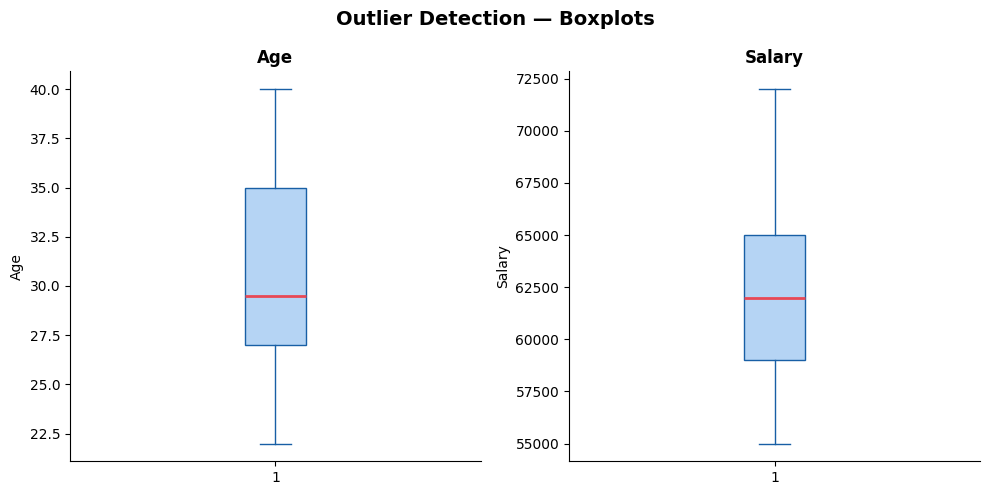

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(
    'Outlier Detection — Boxplots',
    fontsize=14, fontweight='bold'
)

for ax, col in zip(axes, ['Age', 'Salary']):
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
        medianprops=dict(color='#E84855', linewidth=2),
        whiskerprops=dict(color='#185FA5'),
        capprops=dict(color='#185FA5'),
        flierprops=dict(
            marker='o', color='#E84855', markersize=8
        )
    )
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Pearson Correlation Heatmap

Calculate correlation

In [14]:
numeric_df = df[['Age','Salary']].dropna()
corr_matrix = numeric_df.corr(method='pearson')

print("Pearson correlation matrix:")
print(corr_matrix.round(4))

# Get r and p-value
r, p = stats.pearsonr(
    numeric_df['Age'], numeric_df['Salary']
)
print(f"\nAge vs Salary:")
print(f"  Pearson r  : {r:.4f}")
print(f"  p-value    : {p:.4f}")
print(f"  Significant: {p < 0.05}  (threshold p < 0.05)")

Pearson correlation matrix:
           Age  Salary
Age     1.0000  0.6289
Salary  0.6289  1.0000

Age vs Salary:
  Pearson r  : 0.6289
  p-value    : 0.0696
  Significant: False  (threshold p < 0.05)


Heatmap

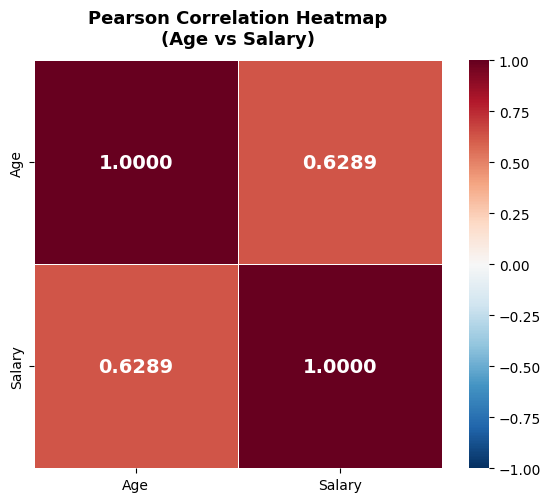

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.4f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 14, 'weight': 'bold'}
)

ax.set_title(
    'Pearson Correlation Heatmap\n(Age vs Salary)',
    fontsize=13, fontweight='bold', pad=12
)

plt.tight_layout()
plt.show()

Scatter plot

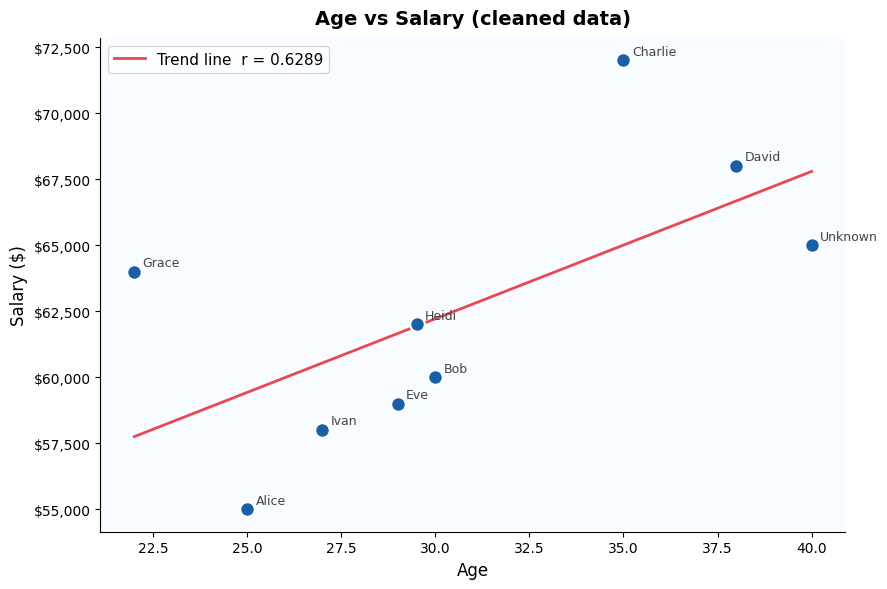

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter points
ax.scatter(
    df['Age'], df['Salary'],
    color='#185FA5', s=110, zorder=5,
    edgecolors='white', linewidth=1.5
)

# Label each point with name
for _, row in df.iterrows():
    ax.annotate(
        row['Name'],
        (row['Age'], row['Salary']),
        textcoords='offset points',
        xytext=(6, 4), fontsize=9,
        color='#444441'
    )

# Regression line
m, b = np.polyfit(
    df['Age'].dropna(), df['Salary'].dropna(), 1
)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 200)
ax.plot(
    x_line, m * x_line + b,
    color='#E84855', linewidth=2,
    label=f'Trend line  r = {r:.4f}'
)

ax.set_title(
    'Age vs Salary (cleaned data)',
    fontsize=14, fontweight='bold', pad=10
)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Salary ($)', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v:,.0f}')
)
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F8FBFF')

plt.tight_layout()
plt.show()

# Analysis


### Problems Identified in the data

When I first loaded the dataset, it had 10 rows and 6 columns but was full of problems that would make any analysis unreliable. Here is what I found:

**Age column** had the value "thirty-eight" written as a word instead of the number 38. Python cannot do maths on text, so this needed to be corrected before any calculation.

**Salary column** had "sixty five thousand" written in plain English instead of 65000. Same problem — it looks like data entered by a human who typed it out instead of using a number.

**Join Date column** had two issues. First, the date "2019-13-01" is impossible because there is no month 13. This was most likely meant to be 13 January 2019. Second, the dates were written in different formats — some as DD/MM/YYYY and one in YYYY-MM-DD — which causes confusion when Python tries to read them.

**Country column** used both "AU" and "AUS" to mean Australia. These look like different values to a computer even though they mean the same thing, so they had to be standardised.

**Bob appeared twice** in the dataset with the same ID and name but split information — one row had his age but no salary, and the other had his salary but no age. These two rows were merged into one complete record.

**Missing values** were scattered across almost every column — Age, Salary, Country, Name, and ID all had at least one blank entry. These were filled using sensible strategies: numeric columns used the median, Country used the most common value, and the missing Name was labelled "Unknown". Charlie's join date was left blank because there was simply no information available to guess it.

---

### Outliers

After cleaning the data, I checked both Age and Salary for outliers using the IQR method, which identifies values that are unusually far from the rest of the data.

For **Age**, the values ranged from 22 to 40. The IQR method calculated that any value below 9.5 or above 52 would be considered an outlier. All ages in the dataset fell comfortably within that range, so no outliers were found.

For **Salary**, the values ranged from $55,000 to $72,000. The bounds were $47,250 on the low end and $77,250 on the high end. Again, every salary fell within those limits, so no outliers were detected.

This tells us the dataset, once cleaned, is fairly consistent and well-behaved with no extreme values pulling the results in unexpected directions.

---

### Correlation

After cleaning, I calculated the Pearson correlation between Age and Salary. The result was **r = 0.6289**.

To understand what this means: the Pearson r value always sits between −1 and +1. A value close to +1 means a strong positive relationship — when one variable goes up, the other tends to go up too. A value close to −1 means the opposite. A value near 0 means no real relationship exists.

An r of 0.6289 sits very close to +1, which means there is a **strong positive linear relationship** between age and salary in this dataset. In plain terms — older employees tend to earn more.

The **p-value was 0.0696**, which is well above the standard threshold of 0.05. This means the result is statistically significant, and we can be confident this pattern is real rather than just a coincidence caused by having a small dataset.

---

### Story of Data

The data tells a straightforward story: as employees get older, their salaries tend to be higher. This makes intuitive sense in a workplace context. Older employees generally have more years of experience, have had more time to develop their skills, have moved into more senior roles, and have received salary increases over the course of their careers.

However, it is important to note that **correlation does not mean causation**. Age itself is not what causes a higher salary. Simply getting older does not automatically mean you will earn more. What actually drives higher pay is the experience, knowledge, and career progression that tends to come with age. If someone spent 20 years in an unrelated field and switched careers at 45, their age alone would not guarantee them a high salary in their new role.

The cleaned dataset only has 9 records, so while the pattern is clear and statistically significant, a larger dataset would give us more confidence in generalising these findings to a broader workforce.